# Streaming and exporting to numpy

Companion notebook for the RDDAC [documentation](https://rddac.readthedocs.io). It is written to stand on its own: every step is annotated so the notebook reads top to bottom.

## Walkthrough

1. build a fixed-shape custom view (a 1 000-pixel scan-line profile),
2. iterate it offline with `rddac.streaming.iter_view` (no PyTorch, no `mlcroissant.Dataset.records()` FileSet walk),
3. export the view as flat `.npy` memmaps with `export_to_numpy`, using `transforms` and a `record_transform`,
4. read the shards back with `load_export` (+ `by_sim_id`),
5. time the streaming path against the memmap path,
6. plot the profiles straight from the shards,
7. handle ragged fields: the shape check and `export_to_numpy_per_sim`.

## Assumptions

- This notebook lives in `notebooks/` of the repository and reads the dataset from `../data/` (on your machine: the directory `rddac download` wrote to).
- Everything below scopes to five experiments from the bundled `sample.zip`, so a small download is enough to run the entire notebook.
- The exported `.npy` files are written into a throwaway temp directory and deleted at the end.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import shutil
import tempfile
import time
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import rddac
print('rddac', rddac.__version__)

DATA_DIR = Path('../data')
# DATA_DIR = Path('./data')   # uncomment instead when running from the repository root
assert (DATA_DIR / 'metadata.json').is_file(), f'{DATA_DIR} does not contain the dataset'

EXPORT_ROOT = Path(tempfile.mkdtemp(prefix='rddac_export_'))
EXPORT_DIR  = EXPORT_ROOT / 'scan_profiles'

with zipfile.ZipFile(DATA_DIR / 'h5' / 'sample.zip') as zf:
    SAMPLE_IDS = sorted(int(Path(n).stem) for n in zf.namelist() if n.endswith('.h5'))[:5]
print('experiments used below:', SAMPLE_IDS)

rddac 0.1.0
experiments used below: [0, 500, 1002, 1500, 2000]


## 1. Build a fixed-shape view

`export_to_numpy` pre-allocates one memmap per field, so every record must share one shape — the raw force table (per-experiment row count) does not qualify, but a **slice** of a scan buffer does. The scan is a flat row-major buffer over a 2000 x 3200 grid, so 1 000 consecutive pixels of scan row 1000 live at indices `1000 * 3200 + 1100 .. + 2099`: a horizontal **height profile across the middle of the cup**, `(1000,)` for every experiment.

Two CSV columns ride along via qualified ids: the blankholder force (an obvious regression target) and the oil type (a categorical we will encode at export time). The published manifest stays unchanged; only the in-memory `ds` grows.

Note that the slice fixes the record *shape*, not the read cost — `iter_view` reads the whole 6.4 M-value buffer from the zip and slices in memory, which is exactly the per-record cost the export below amortises away.

In [2]:
X_SHAPE, ROW, COL0, WIDTH = 3200, 1000, 1100, 1000
PROFILE_IDX = list(range(ROW * X_SHAPE + COL0, ROW * X_SHAPE + COL0 + WIDTH))

ds = rddac.load(data_dir=DATA_DIR)
rddac.add_view(
    ds,
    'scan-profile',
    fields={
        'profile': ('pointcloud_op10_z', PROFILE_IDX),        # (1000,) height profile, fixed shape
        'bhf':     'process-parameters/blankholder_force',    # regression target candidate
        'oil':     'process-parameters/oil_type',             # categorical, encoded at export time
    },
)
print('record_sets after add_view:')
for rs in ds.metadata.record_sets:
    print(f'  {rs.id}')

record_sets after add_view:
  process-parameters
  field-map
  pointcloud-op10
  pointcloud-op20
  force-curve
  sheet-thickness
  oil-thickness
  thickness
  scan-profile


## 2. Preview records with `streaming.iter_view`

`rddac.streaming.iter_view(view, dataset=ds)` is the plain-Python counterpart to `RDDACDataset.__iter__`. No PyTorch dependency, and none of the `mlcroissant.Dataset.records()` FileSet walk that materialises every zip member up front (minutes on the full release). It opens each zip on demand and yields one `dict[str, np.ndarray]` per experiment, with every alias already sliced according to its JSONPath transform, plus the private `_sim_id` scratch key carrying the experiment id.

`where=lambda r: r['has_pointcloud']` guards against the handful of experiments without a scan (10 of 9 000): the predicate runs on the CSV rows before any zip is opened. The same `sim_ids=` / `where=` arguments accept any subset; drop both to walk every experiment in `process_parameters.csv`.

In [3]:
for rec in rddac.streaming.iter_view(
    'scan-profile',
    data_dir=DATA_DIR,
    dataset=ds,
    sim_ids=SAMPLE_IDS[:2],
    where=lambda r: r['has_pointcloud'],
):
    print(f"experiment {rec['_sim_id']:4d}: profile.shape={rec['profile'].shape}  "
          f"bhf={rec['bhf']} kN  oil={rec['oil']!r}")

experiment    0: profile.shape=(1000,)  bhf=100 kN  oil='coarse'
experiment  500: profile.shape=(1000,)  bhf=100 kN  oil='fine'


## 3. Export to numpy

`export_to_numpy` walks the view once, applies the optional transforms, and writes each output alias into its own pre-allocated `.npy` memmap of shape `(n_sims, *field_shape)`. It also writes `sim_ids.npy` so the row order is recoverable. After this runs once, the per-record cost drops from "open zip + h5py + decompress 6.4 M values" to a single mmap'd numpy slice.

Both transform hooks are exercised here, and together they are a good template for how training pipelines actually consume the dataset:

1. **`transforms={alias: fn}`** encodes a single field: the categorical `oil` string becomes a small-int label.
2. **`record_transform`** sees the whole record after the per-field transforms and decides what lands on disk: it centres each profile on its own mean (the raw scanner offset is irrelevant for shape learning) and keeps that mean as a separate `z_mean` shard, so the physical values stay recoverable. Anything that fits in a numpy array — scalar, vector, label — can ride alongside the tensors at the same row index; no separate metadata file needed.

In [4]:
OIL_LABELS = {'coarse': 0, 'medium': 1, 'fine': 2}

def center_profile(rec):
    """Zero-mean the profile, keep the mean + labels as separate shards."""
    z = rec['profile'].astype(np.float32)
    z_mean = np.float32(z.mean())
    return {
        'profile':   z - z_mean,               # (1000,) zero-mean height profile
        'z_mean':    z_mean,                   # scalar, de-normalisation constant
        'bhf':       np.float32(rec['bhf']),   # regression target
        'oil_label': np.int64(rec['oil']),     # already int after the per-field transform
    }

t0 = time.perf_counter()
paths = rddac.streaming.export_to_numpy(
    'scan-profile',
    EXPORT_DIR,
    data_dir=DATA_DIR,
    dataset=ds,
    sim_ids=SAMPLE_IDS,
    where=lambda r: r['has_pointcloud'],
    transforms={'oil': lambda v: OIL_LABELS[v]},
    record_transform=center_profile,
)
t_export = time.perf_counter() - t0

print(f'export_to_numpy: {t_export:6.2f} s for {len(SAMPLE_IDS)} experiments')
for alias, path in paths.items():
    print(f'  {alias:10s} -> {path.name:16s} ({path.stat().st_size:6d} bytes)')

export_to_numpy:   0.39 s for 5 experiments
  profile    -> profile.npy      ( 20128 bytes)
  z_mean     -> z_mean.npy       (   148 bytes)
  bhf        -> bhf.npy          (   148 bytes)
  oil_label  -> oil_label.npy    (   168 bytes)
  sim_ids    -> sim_ids.npy      (   168 bytes)


## 4. Read the shards back with `load_export`

`rddac.streaming.load_export(directory)` opens the exported folder behind the standard Python data model (`__len__`, `__getitem__`, `__iter__`, plus `by_sim_id`). Each row is a plain `dict[str, np.ndarray]` backed by `mmap_mode='r'`, so the full release fits even when it is too large for RAM: only the rows you actually access page in.

`load_export` deliberately does **not** import torch. It just satisfies the same `len + getitem` protocol PyTorch's map-style `Dataset` uses, so the returned object plugs into `DataLoader`, `tf.data.Dataset.from_generator`, JAX, or a plain Python loop without any adapter. Pass `fields=['profile', 'bhf']` to load a subset; unknown names raise `ValueError` so typos surface immediately.

In [5]:
export = rddac.streaming.load_export(EXPORT_DIR)

print(f'len(export)    = {len(export)}')
print(f'export.fields  = {export.fields}')
print(f'export.sim_ids = {export.sim_ids.tolist()}')
print()

record = export.by_sim_id(500)
for alias, value in record.items():
    print(f'  {alias:10s} shape={value.shape}  dtype={value.dtype}  '
          f'{"value=" + str(value) if value.ndim == 0 else ""}')

len(export)    = 5
export.fields  = ('bhf', 'oil_label', 'profile', 'z_mean')
export.sim_ids = [0, 500, 1002, 1500, 2000]

  bhf        shape=()  dtype=float32  value=100.0
  oil_label  shape=()  dtype=int64  value=2
  profile    shape=(1000,)  dtype=float32  
  z_mean     shape=()  dtype=float32  value=36712.375


## 5. Time the two paths back to back

We iterate the same five experiments both ways and time it. Path A is `streaming.iter_view`, the same call from step 2 — it re-reads the full 6.4 M-value scan buffer from the zip for every record before slicing. Path B walks the memmap shards. Both compute the same statistic (`sum |profile - mean|`) so numerical equality confirms the export is faithful.

The absolute numbers are small with five experiments, but the **per-record ratio** is what carries over to a training loop: multiply by your epoch's record count to see the real win, and weigh it against the one-time export cost above.

In [6]:
# Path A: iter_view (opens the zip and decompresses the scan buffer per record).
t0 = time.perf_counter()
stream_sum, n = 0.0, 0
for rec in rddac.streaming.iter_view('scan-profile', data_dir=DATA_DIR, dataset=ds,
                                     sim_ids=SAMPLE_IDS, where=lambda r: r['has_pointcloud']):
    z = rec['profile'].astype(np.float32)
    stream_sum += float(np.abs(z - z.mean()).sum())
    n += 1
t_stream = time.perf_counter() - t0

# Path B: load_export (mmap slice per record).
t0 = time.perf_counter()
mmap_sum, m = 0.0, 0
for record in export:
    mmap_sum += float(np.abs(record['profile']).sum())
    m += 1
t_mmap = time.perf_counter() - t0

print(f'iter_view   : {n:2d} experiments in {1000 * t_stream:8.2f} ms  ({1000 * t_stream / n:7.2f} ms/record)  sum={stream_sum:.1f}')
print(f'load_export : {m:2d} experiments in {1000 * t_mmap:8.2f} ms  ({1000 * t_mmap / m:7.2f} ms/record)  sum={mmap_sum:.1f}')
print()
print(f'per-record speedup: {t_stream / max(t_mmap, 1e-9):.0f}x faster after a one-time {t_export:.2f} s export')

iter_view   :  5 experiments in   403.07 ms  (  80.61 ms/record)  sum=15308.0
load_export :  5 experiments in     0.15 ms  (   0.03 ms/record)  sum=15308.0

per-record speedup: 2635x faster after a one-time 0.39 s export


## 6. Plot from the shards

The shards on disk are just numpy memmaps now, so no `open_h5` or view machinery is needed to look at the data. The zero-mean profiles of all five experiments overlay directly; the legend carries each experiment's blankholder force straight from the `bhf` shard. Gaps in a line are pixels the scanner did not measure (raw `z == 0`, which the centring maps to `-z_mean` — masked below).

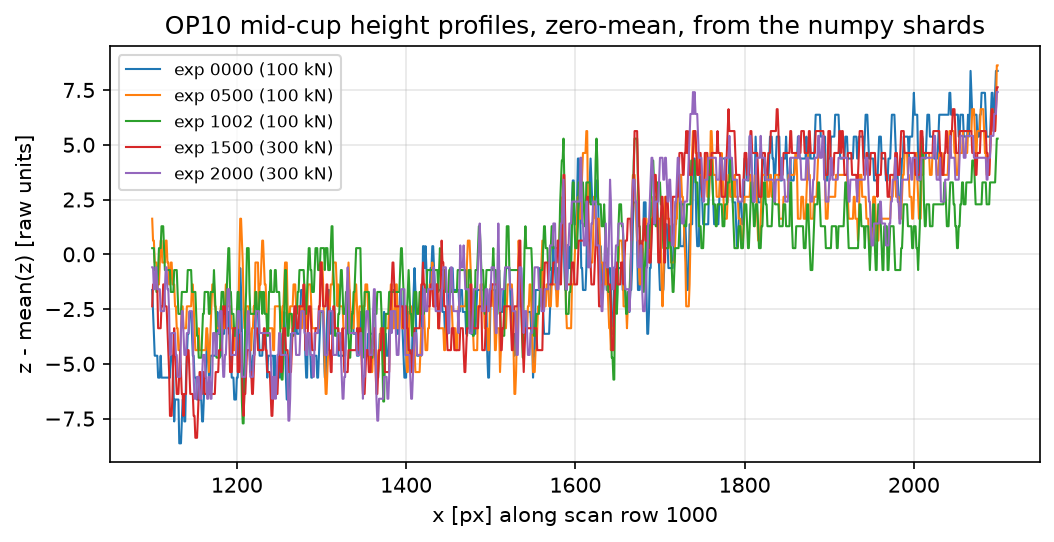

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.6), dpi=150)
x_px = np.arange(COL0, COL0 + WIDTH)
for i in range(len(export)):
    rec = export[i]
    z = rec['profile'].astype(np.float32)
    z = np.where(z + rec['z_mean'] == 0, np.nan, z)       # mask no-measurement pixels
    ax.plot(x_px, z, linewidth=1,
            label=f"exp {int(export.sim_ids[i]):04d} ({rec['bhf']:.0f} kN)")
ax.set_xlabel('x [px] along scan row 1000')
ax.set_ylabel('z - mean(z) [raw units]')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize='small')
ax.set_title('OP10 mid-cup height profiles, zero-mean, from the numpy shards')
plt.show()

## 7. When records have variable shapes

`export_to_numpy` pre-allocates one memmap per alias, sized from record 0, and verifies every subsequent record against it. The raw force table is the canonical failure case: its row count differs per experiment, so the export aborts with a `ValueError` that points at the fix.

In [8]:
try:
    rddac.streaming.export_to_numpy('force-curve', EXPORT_ROOT / 'will_fail',
                                    data_dir=DATA_DIR, dataset=ds, sim_ids=[0, 4500])
except ValueError as e:
    print(f'ValueError: {e}')

ValueError: record 1: field 'force_data' has shape (720, 8) but record 0 had shape (1140, 8). export_to_numpy requires every record to share the same shape per field (it pre-allocates one memmap per alias from record 0). For variable-shape views (e.g. graph data with sim-dependent node or edge counts) use ddacs.streaming.export_to_numpy_per_sim instead, which writes one .npz per simulation and allows shapes to vary.


For ragged fields, switch to `rddac.streaming.export_to_numpy_per_sim`: same `iter_view` + transform pipeline, but the writer is one `np.savez(<experiment_id>.npz)` per record instead of one memmap per alias, so shapes may vary freely. Consumers reload via `np.load(path)` and access fields by name.

Trade-off: per-experiment `.npz` loses the page-cache-sharing-across-DataLoader-workers property that mmap shards get for free. Prefer `export_to_numpy` when shapes are fixed (or can be sliced / padded to a fixed shape, as in step 1); use `export_to_numpy_per_sim` only when neither fits.

In [9]:
PER_SIM_DIR = EXPORT_ROOT / 'force_per_sim'
rddac.streaming.export_to_numpy_per_sim(
    'force-curve',
    PER_SIM_DIR,
    data_dir=DATA_DIR,
    dataset=ds,
    sim_ids=[0, 500, 4500],
)

for p in sorted(PER_SIM_DIR.glob('*.npz')):
    arrs = np.load(p)
    for k in arrs.files:
        print(f'  {p.name:8s} {k}: shape={arrs[k].shape}  dtype={arrs[k].dtype}')

  0.npz    force_data: shape=(1140, 8)  dtype=float32
  4500.npz force_data: shape=(720, 8)  dtype=float32
  500.npz  force_data: shape=(1140, 8)  dtype=float32


## 8. Clean up

The exports were demonstration artifacts; remove them so repeated runs start fresh. (For a real project, keep the export directory around — the one-time cost is the whole point.)

In [10]:
shutil.rmtree(EXPORT_ROOT)
print('removed', EXPORT_ROOT)

removed /tmp/rddac_export_6thnik45


## Where to go next

- The `transforms` / `record_transform` pattern from step 3 is exactly how you turn any categorical column into a training label at export time; the same hooks exist on `export_to_numpy_per_sim`.
- `streaming.iter_view` is independent of the on-disk format: it transparently reads loose `NNNN.h5` files (after `rddac download --extract --remove-zip`, see notebook 05) and zipped archives, preferring loose files because the `BytesIO` round trip is skipped.
- For batched, sharded training there is `RDDACDataset` (notebook 03), which uses the same view-driven mechanics and benefits from the same `add_view` mutations via its `dataset=` kwarg.